# 02 Exploratory Data Analysis

This notebook explores inspection distributions, trends over time, score behavior, and borough-level patterns in the filtered 2022 to 2025 data.

In [16]:
# Author: Jessica
# Loading cleaned data so this notebook runs independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_filtered_2022_2025 = pd.read_csv("shared_data/cleaned_inspections.csv", parse_dates=['INSPECTION DATE'])
print(df_filtered_2022_2025.shape)
df_filtered_2022_2025.head()

(271481, 27)


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,41395397,CITI FIELD PAT LAFRIEDA/KOSHER GRILL - STAND 142,Queens,126 ST,and ROOSEVELT AVENUE,NaN,7185958100,American,2025-09-13,No violations were recorded at the time of thi...,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,4.000000e+00,NaN,NaN
1,50104788,LOULOU,Manhattan,176,8 AVENUE,10011.0,9172925624,French,2023-11-08,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.742742,-74.000328,104.0,3.0,8700.0,1013890.0,1.007680e+09,MN13,POINT (-74.000328399123 40.742741971093)
2,41486460,RIVER DELI,Brooklyn,2834,COLUMBIA PLACE,NaN,7182549200,Italian,2022-08-20,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN
3,41585425,LUCKY GARDEN,Bronx,305,WYCKOFF AVENUE,NaN,7184181002,Chinese,2025-12-16,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN
4,50088988,CITY ONE,Manhattan,2726,FREDERICK DOUGLASS BOULEVARD,NaN,2123688818,Chinese,2023-08-31,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN


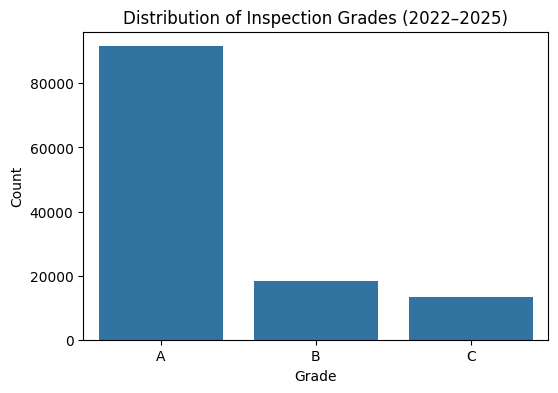

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered_2022_2025, x="GRADE", order=["A","B","C"])

plt.title("Distribution of Inspection Grades (2022–2025)")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

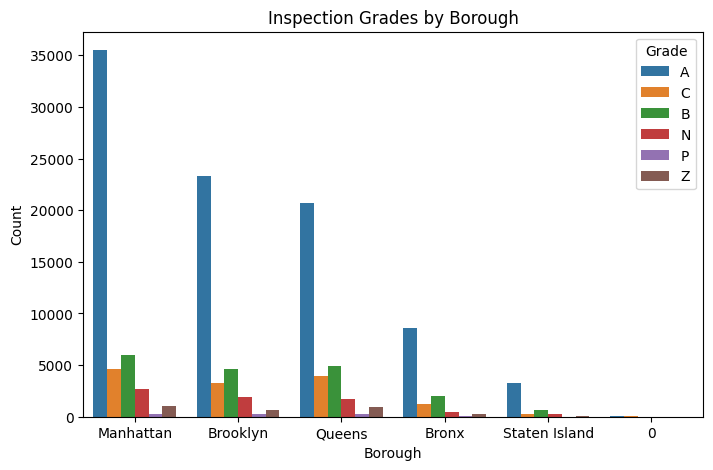

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_filtered_2022_2025,
    x="BORO",
    hue="GRADE",
    order=df_filtered_2022_2025["BORO"].value_counts().index
)

plt.title("Inspection Grades by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.legend(title="Grade")

plt.show()

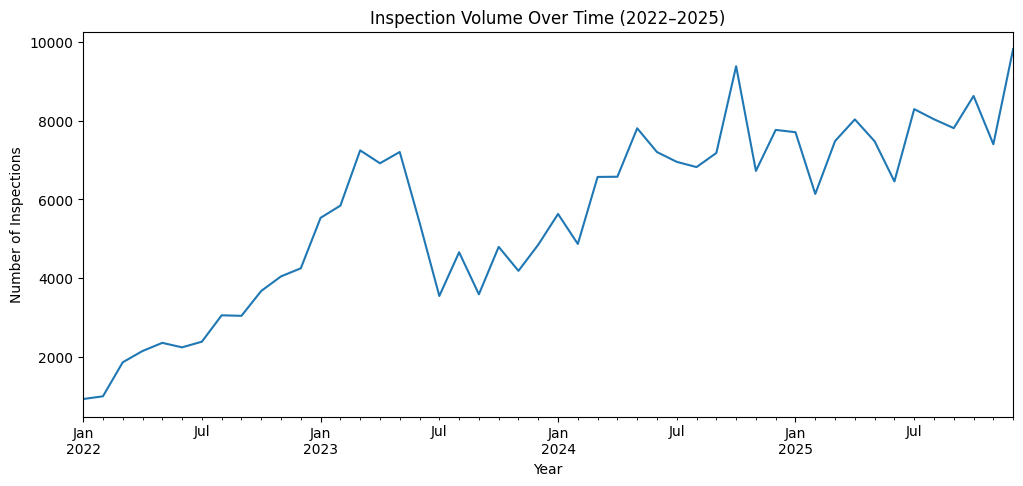

In [19]:
df_filtered_2022_2025["YearMonth"] = df_filtered_2022_2025["INSPECTION DATE"].dt.to_period("M")

monthly = df_filtered_2022_2025.groupby("YearMonth")["CAMIS"].count()

plt.figure(figsize=(12,5))
monthly.plot()

plt.title("Inspection Volume Over Time (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Inspections")

plt.show()

/tmp/ipykernel_32550/2833399416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


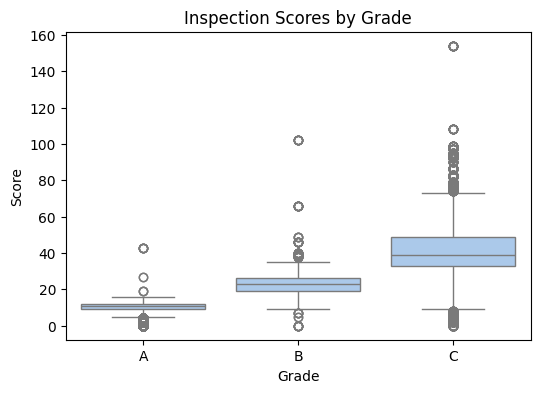

In [20]:
plt.figure(figsize=(6,4))

# lighten the boxplot by using a pastel version of the default blue
sns.boxplot(
    data=df_filtered_2022_2025,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"],
    palette=[sns.color_palette("pastel")[0]]*3  # same light blue for each grade
)

plt.title("Inspection Scores by Grade")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

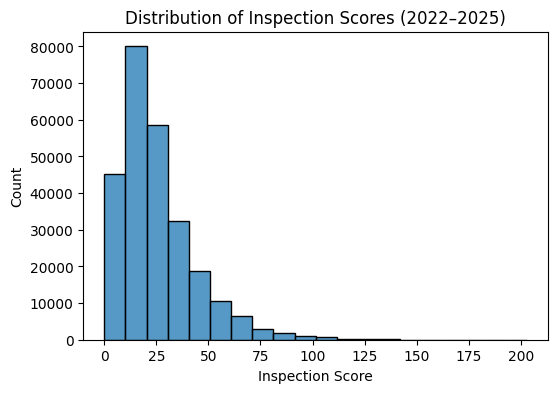

In [21]:
#Histogram of Score distribution (styled like the grade countplot)
plt.figure(figsize=(6,4))

# use seaborn histogram for consistent styling
sns.histplot(
    data=df_filtered_2022_2025,
    x="SCORE",
    bins=20,
    color=sns.color_palette()[0],  # default seaborn blue
    edgecolor="black",
    kde=False,
)

plt.title("Distribution of Inspection Scores (2022–2025)")
plt.xlabel("Inspection Score")
plt.ylabel("Count")

plt.show()

In [22]:
df_filtered_2022_2025['BORO'].unique()

df_Manhattan = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'] == 'Manhattan'
].copy()

df_Manhattan.describe()

,CAMIS,ZIPCODE,INSPECTION DATE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,1.001760e+05,98803.000000,100176,95214.000000,99730.000000,99730.000000,98357.000000,98357.000000,98357.000000,9.794000e+04,9.973000e+04
mean,4.791158e+07,10022.508304,2024-05-12 01:24:58.993771,24.373327,40.192954,-72.962934,105.075348,3.647214,10053.673851,1.037311e+06,9.915770e+08
min,3.019184e+07,10000.000000,2022-01-03 00:00:00,0.000000,0.000000,-74.018001,101.000000,1.000000,201.000000,1.000000e+06,1.000000e+00
25%,5.000096e+07,10010.000000,2023-06-06 00:00:00,12.000000,40.727803,-73.995191,103.000000,2.000000,4700.000000,1.010860e+06,1.004810e+09
50%,5.008811e+07,10017.000000,2024-06-26 00:00:00,20.000000,40.749732,-73.985584,105.000000,3.000000,9200.000000,1.028625e+06,1.008570e+09
75%,5.012675e+07,10027.000000,2025-04-08 00:00:00,32.000000,40.765893,-73.970914,107.000000,4.000000,13400.000000,1.061862e+06,1.013000e+09
max,5.018002e+07,11371.000000,2025-12-31 00:00:00,203.000000,40.872885,0.000000,164.000000,10.000000,31704.000000,1.799161e+06,1.270000e+09
std,3.859850e+06,30.950664,NaN,18.628549,4.748931,8.620616,3.032392,2.369476,6734.157781,3.625018e+04,1.343786e+08


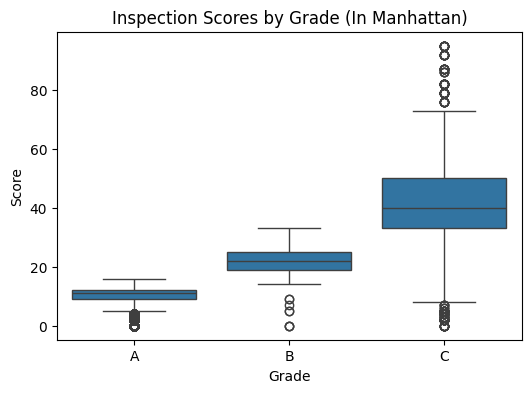

In [23]:
#Grading in Manhattan


plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Manhattan,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Manhattan)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()
#Showing the boxplot throughout the years

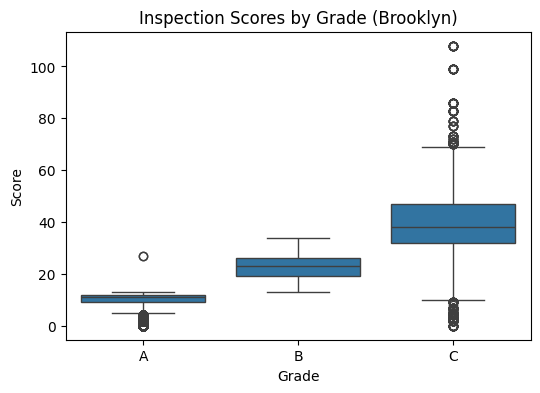

In [24]:
# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Brooklyn
df_Brooklyn = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BROOKLYN'
].copy()

df_Brooklyn.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Brooklyn,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Brooklyn)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

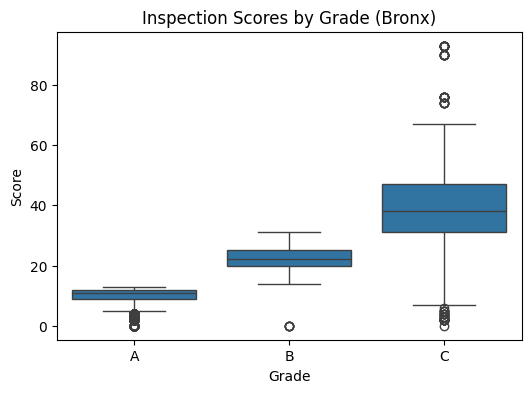

In [25]:

# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Bronx
df_Bronx = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BRONX'
].copy()

df_Bronx.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Bronx,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Bronx)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

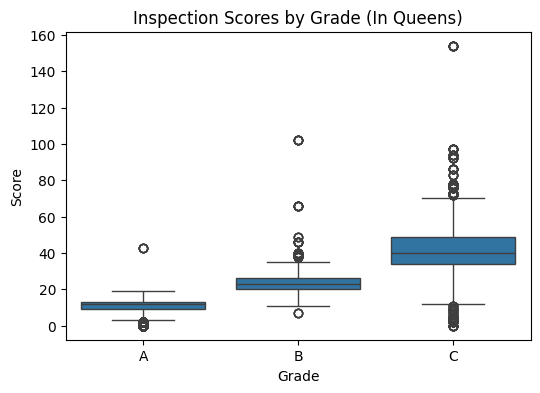

In [26]:
df_filtered_2022_2025.BORO.unique()
df_Queens = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Queens'].copy()
df_Queens.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Queens,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Queens)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

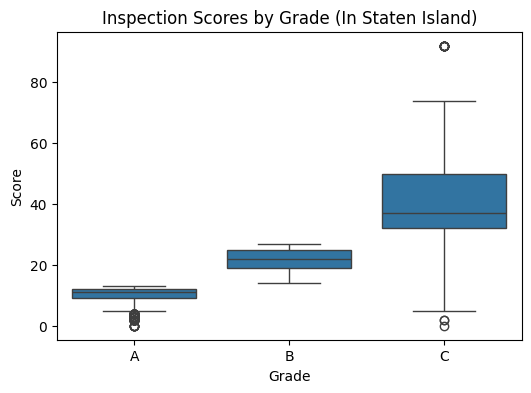

In [27]:
df_filtered_2022_2025.BORO.unique()
df_Staten_Island = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Staten Island'].copy()
df_Staten_Island.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Staten_Island,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Staten Island)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()